In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.preprocessing import ICA

# Load data
data_path = mne.datasets.sample.data_path()
raw_fif_path = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(raw_fif_path, preload=True)

# Pick EEG only
raw.pick('eeg')

# Apply bandpass filter (from Phase 2)
raw.filter(l_freq=0.1, h_freq=40.0)

print("Data loaded and filtered!")
print(f"Channels: {len(raw.ch_names)}, Duration: {raw.times[-1]:.1f} sec")

Opening raw data file /Users/aleksandraszymanska/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 19821 samples (33.001 s)

Data loaded and filtered!
Channels: 60, Duration: 277.7 sec


In [3]:
# Create ICA object
# n_components=15 means we'll extract 15 independent components
ica = ICA(n_components=15, random_state=42)

# Fit ICA to the data (this takes a moment)
ica.fit(raw)

print("ICA fitted")
print(f"Found {ica.n_components_} components")

Fitting ICA to data using 59 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 14.5s.
ICA fitted
Found 15 components


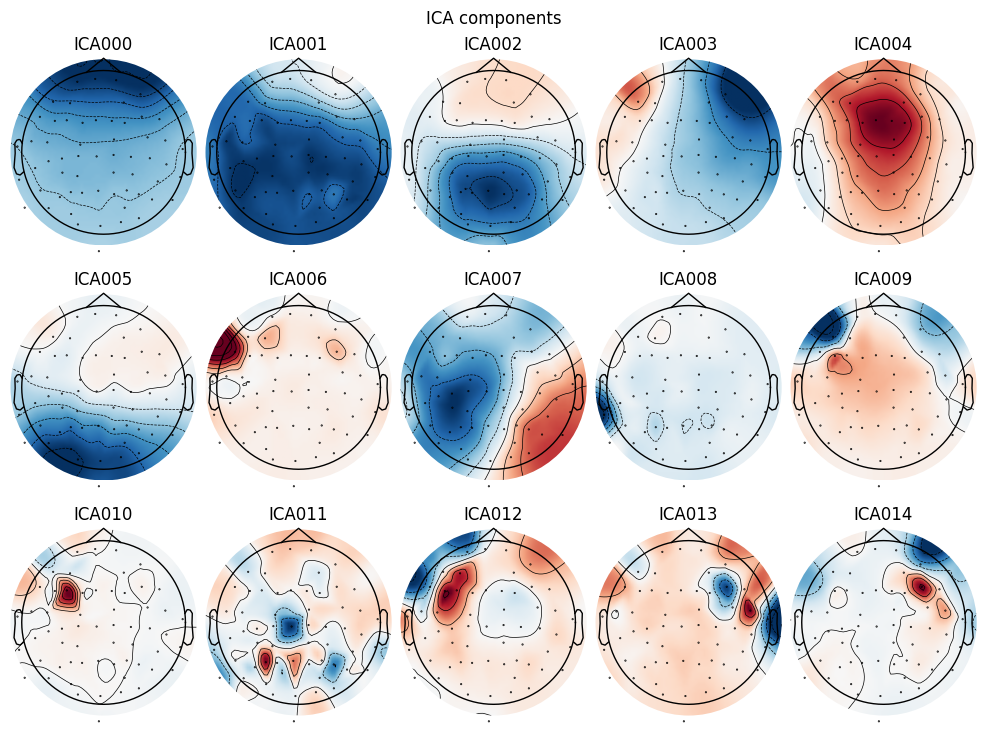

In [4]:
# Plot all ICA components
ica.plot_components(picks=range(15))
plt.show()

In [6]:
# Find components that correlate with EOG (eye movements)
eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name='EEG 001')

print(f"Automatically detected EOG components: {eog_indices}")
print(f"Correlation scores: {eog_scores}")

Using EOG channel: EEG 001
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 6007 samples (10.001 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz

Detected EOG components: [np.int64(0)]


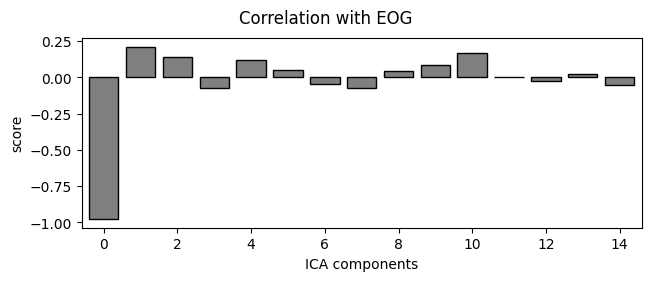

In [7]:
# Print the detected components
print(f"Detected EOG components: {eog_indices}")

# Plot the correlation scores
ica.plot_scores(eog_scores, title='Correlation with EOG')
plt.show()

In [8]:
# Mark component 0 for removal
ica.exclude = [0]

print(f"Components marked for removal: {ica.exclude}")

Components marked for removal: [0]


Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 59 PCA components


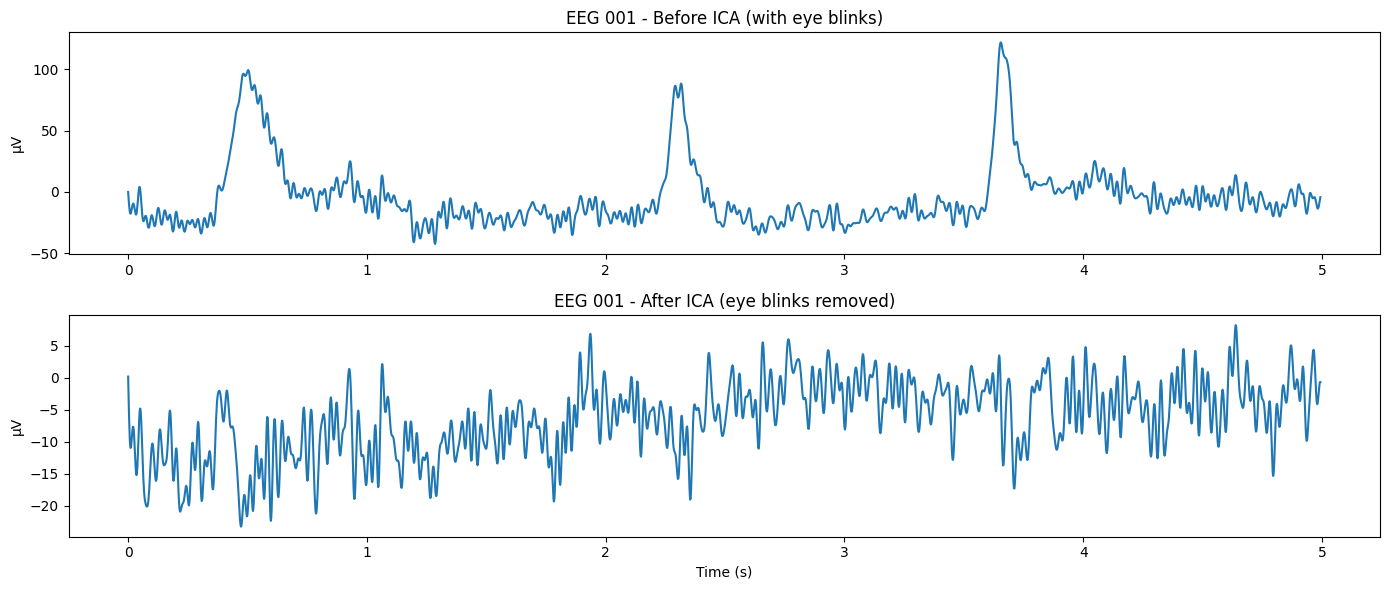

In [9]:
# Apply ICA (remove the bad component)
raw_clean = ica.apply(raw.copy())

# Compare before and after - plot first 5 seconds
channel = raw.ch_names[0]
sfreq = int(raw.info['sfreq'])
n_samples = sfreq * 5

times = raw.times[:n_samples]
data_before = raw.get_data(picks=[channel])[0, :n_samples] * 1e6
data_after = raw_clean.get_data(picks=[channel])[0, :n_samples] * 1e6

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(times, data_before)
axes[0].set_title(f"{channel} - Before ICA (with eye blinks)")
axes[0].set_ylabel("µV")

axes[1].plot(times, data_after)
axes[1].set_title(f"{channel} - After ICA (eye blinks removed)")
axes[1].set_ylabel("µV")
axes[1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

Creating RawArray with float64 data, n_channels=6, n_times=166800
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


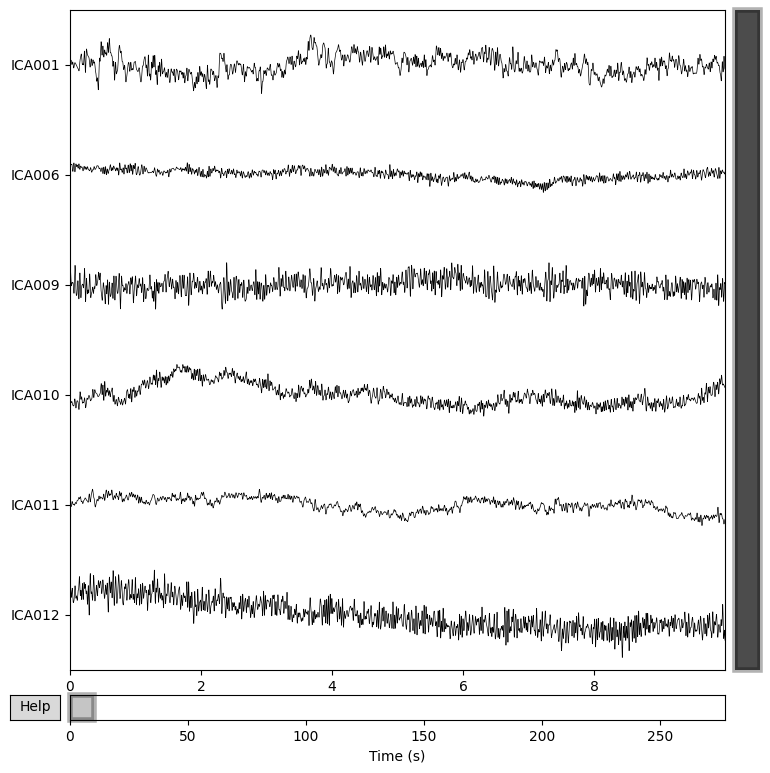

In [14]:
# Look at the time courses of suspicious components
ica.plot_sources(raw, picks=[1, 6, 9, 10, 11, 12], start=0, stop=10)
plt.show()